# Notebook 1 — Diagnóstico de Overfitting com MLP

**Objetivo didático:** identificar sinais de overfitting em um problema de classificação supervisionada e decidir quais intervenções fazem sentido.

## O que você deve aprender
- Diferenciar desempenho de treino e validação.
- Reconhecer evidências de memorização.
- Alterar o código de forma justificada, não apenas por tentativa e erro.
- Comparar o efeito de regularização L2 e dropout.

## Tarefa
1. Execute o notebook sem alterações.
2. Observe curvas e métricas.
3. Diagnostique o problema.
4. Modifique o modelo e/ou o otimizador.
5. Registre o que mudou e por quê.

## Perguntas orientadoras
- O modelo generaliza bem?
- Que evidências sustentam sua conclusão?
- Qual seria sua primeira intervenção?
- Em que ponto a regularização ajuda de fato?

In [1]:
import math
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Verificar se a GPU está disponível
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f'Usando o dispositivo: {device}')

Usando o dispositivo: cpu


## 1. Geração do dataset

Neste cenário, o conjunto de dados é propositalmente **pequeno** para aumentar a chance de overfitting.

In [2]:
X, y = make_classification(
    n_samples=240,
    n_features=20,
    n_informative=8,
    n_redundant=4,
    n_classes=2,
    class_sep=1.0,
    flip_y=0.03,
    random_state=SEED
)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.35, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=16, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=64, shuffle=False)

X_train_t.shape, X_val_t.shape

(torch.Size([156, 20]), torch.Size([84, 20]))

## 2. Modelo inicial

**Importante:** o modelo abaixo foi montado para ter **capacidade alta** em relação ao tamanho do dataset.

### Sua análise
Antes de alterar qualquer coisa, pergunte:
- A arquitetura parece grande demais?
- Há algum mecanismo explícito de regularização?

In [3]:
class MLPOverfit(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.net(x)

model = MLPOverfit(X_train_t.shape[1]).to(device)
model

MLPOverfit(
  (net): Sequential(
    (0): Linear(in_features=20, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=2, bias=True)
  )
)

In [4]:
criterion = nn.CrossEntropyLoss()

# CENÁRIO INICIAL: sem regularização explícita
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# TODO:
# Teste versões com weight_decay, por exemplo:
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

In [5]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_correct = 0
    total = 0

    with torch.set_grad_enabled(is_train):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            total_correct += (preds == yb).sum().item()
            total += xb.size(0)

    return total_loss / total, total_correct / total


def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=120):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(epochs):
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer)
        va_loss, va_acc = run_epoch(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)

        if epoch % 10 == 0 or epoch == epochs - 1:
            print(
                f"Epoch {epoch:03d} | "
                f"train_loss={tr_loss:.4f} val_loss={va_loss:.4f} | "
                f"train_acc={tr_acc:.4f} val_acc={va_acc:.4f}"
            )

    return history

In [6]:
history = train_model(model, train_loader, val_loader, criterion, optimizer, epochs=120)

Epoch 000 | train_loss=0.6822 val_loss=0.6709 | train_acc=0.5641 val_acc=0.5952
Epoch 010 | train_loss=0.0870 val_loss=0.8946 | train_acc=0.9744 val_acc=0.6429
Epoch 020 | train_loss=0.0026 val_loss=1.6975 | train_acc=1.0000 val_acc=0.6190
Epoch 030 | train_loss=0.0008 val_loss=1.9900 | train_acc=1.0000 val_acc=0.5952
Epoch 040 | train_loss=0.0004 val_loss=2.1821 | train_acc=1.0000 val_acc=0.6071
Epoch 050 | train_loss=0.0002 val_loss=2.3384 | train_acc=1.0000 val_acc=0.6190
Epoch 060 | train_loss=0.0001 val_loss=2.4570 | train_acc=1.0000 val_acc=0.6190
Epoch 070 | train_loss=0.0001 val_loss=2.5569 | train_acc=1.0000 val_acc=0.6190
Epoch 080 | train_loss=0.0001 val_loss=2.6432 | train_acc=1.0000 val_acc=0.6190
Epoch 090 | train_loss=0.0001 val_loss=2.7221 | train_acc=1.0000 val_acc=0.6190
Epoch 100 | train_loss=0.0000 val_loss=2.7929 | train_acc=1.0000 val_acc=0.6190
Epoch 110 | train_loss=0.0000 val_loss=2.8547 | train_acc=1.0000 val_acc=0.6190
Epoch 119 | train_loss=0.0000 val_loss=2

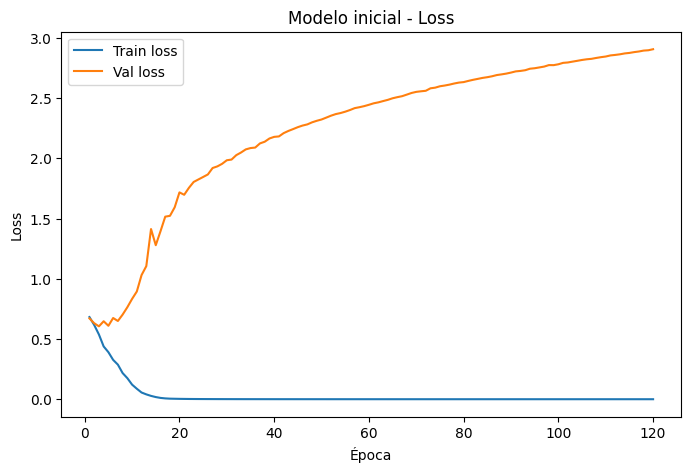

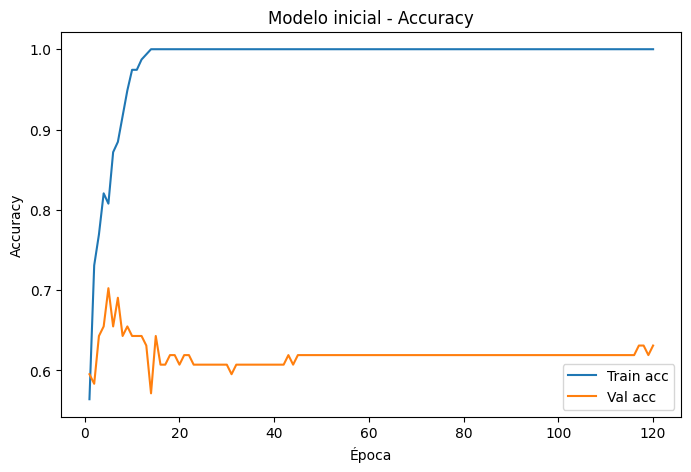

In [7]:
def plot_history(history, title="Histórico de treino"):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], label="Train loss")
    plt.plot(epochs, history["val_loss"], label="Val loss")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.title(title + " - Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_acc"], label="Train acc")
    plt.plot(epochs, history["val_acc"], label="Val acc")
    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.title(title + " - Accuracy")
    plt.legend()
    plt.show()

plot_history(history, title="Modelo inicial")

## 3. Diagnóstico

Preencha antes de alterar o código:

- **Sinal principal observado:**  
- **Há gap entre treino e validação?**  
- **O modelo parece subajustado, equilibrado ou sobreajustado?**  
- **Qual alteração você faria primeiro? Por quê?**

## 4. Intervenções sugeridas

Teste uma alteração por vez:
1. Adicionar `weight_decay`.
2. Inserir `Dropout`.
3. Reduzir a largura das camadas.
4. Comparar combinações.

**Não mude tudo de uma vez.** Você deve conseguir justificar o efeito de cada intervenção.

Epoch 000 | train_loss=0.6948 val_loss=0.6792 | train_acc=0.5000 val_acc=0.5714
Epoch 010 | train_loss=0.4590 val_loss=0.6346 | train_acc=0.7821 val_acc=0.6310
Epoch 020 | train_loss=0.2989 val_loss=0.6932 | train_acc=0.8590 val_acc=0.6071
Epoch 030 | train_loss=0.1651 val_loss=0.7932 | train_acc=0.9487 val_acc=0.6310
Epoch 040 | train_loss=0.1145 val_loss=0.9044 | train_acc=0.9744 val_acc=0.6071
Epoch 050 | train_loss=0.0925 val_loss=1.2189 | train_acc=0.9808 val_acc=0.6548
Epoch 060 | train_loss=0.0344 val_loss=1.3787 | train_acc=1.0000 val_acc=0.6548
Epoch 070 | train_loss=0.0430 val_loss=1.5239 | train_acc=0.9872 val_acc=0.6548
Epoch 080 | train_loss=0.0486 val_loss=1.7424 | train_acc=0.9744 val_acc=0.6548
Epoch 090 | train_loss=0.0788 val_loss=1.6445 | train_acc=0.9679 val_acc=0.6667
Epoch 100 | train_loss=0.0309 val_loss=1.9000 | train_acc=0.9936 val_acc=0.6548
Epoch 110 | train_loss=0.0290 val_loss=2.0703 | train_acc=0.9872 val_acc=0.6429
Epoch 119 | train_loss=0.0090 val_loss=2

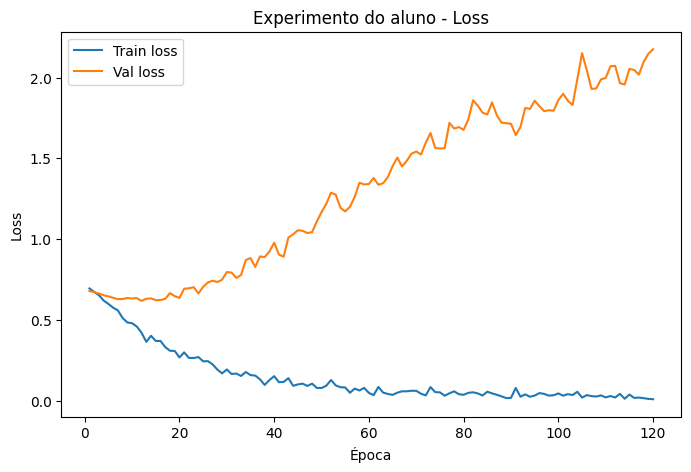

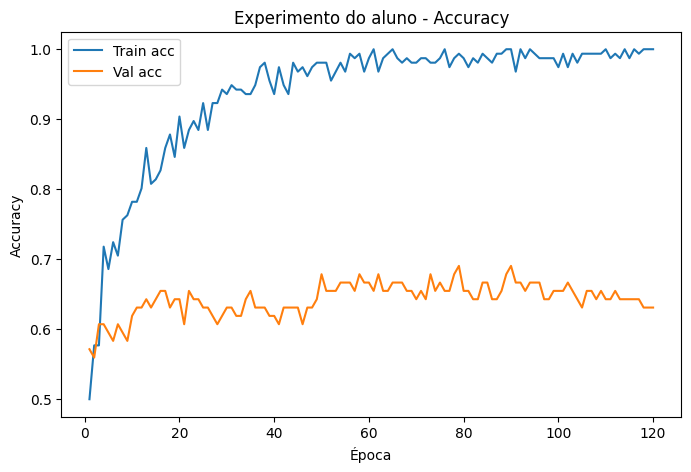

In [8]:
# ÁREA DE EXPERIMENTAÇÃO - Aqui você pode testar novas hipóteses para melhorar a generalização do modelo.
# Copie e adapte este bloco para testar novas hipóteses.

class MLPRegularized(nn.Module):
    def __init__(self, input_dim, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.net(x)

model_exp = MLPRegularized(X_train_t.shape[1], dropout=0.3).to(device)
optimizer_exp = torch.optim.Adam(model_exp.parameters(), lr=1e-3, weight_decay=1e-4)

history_exp = train_model(model_exp, train_loader, val_loader, criterion, optimizer_exp, epochs=120)
plot_history(history_exp, title="Experimento do aluno")

--- Rodando Experimento 1: Baseline ---
Epoch 000 | train_loss=0.6798 val_loss=0.6620 | train_acc=0.5513 val_acc=0.6190
Epoch 010 | train_loss=0.0947 val_loss=0.9393 | train_acc=0.9744 val_acc=0.6786
Epoch 020 | train_loss=0.0033 val_loss=1.3891 | train_acc=1.0000 val_acc=0.6786
Epoch 030 | train_loss=0.0010 val_loss=1.5929 | train_acc=1.0000 val_acc=0.6905
Epoch 040 | train_loss=0.0005 val_loss=1.7226 | train_acc=1.0000 val_acc=0.6905
Epoch 050 | train_loss=0.0003 val_loss=1.8084 | train_acc=1.0000 val_acc=0.6905
Epoch 060 | train_loss=0.0002 val_loss=1.8882 | train_acc=1.0000 val_acc=0.6905
Epoch 070 | train_loss=0.0002 val_loss=1.9492 | train_acc=1.0000 val_acc=0.6905
Epoch 080 | train_loss=0.0001 val_loss=2.0069 | train_acc=1.0000 val_acc=0.6905
Epoch 090 | train_loss=0.0001 val_loss=2.0585 | train_acc=1.0000 val_acc=0.6905
Epoch 100 | train_loss=0.0001 val_loss=2.1033 | train_acc=1.0000 val_acc=0.6905
Epoch 110 | train_loss=0.0001 val_loss=2.1407 | train_acc=1.0000 val_acc=0.6905


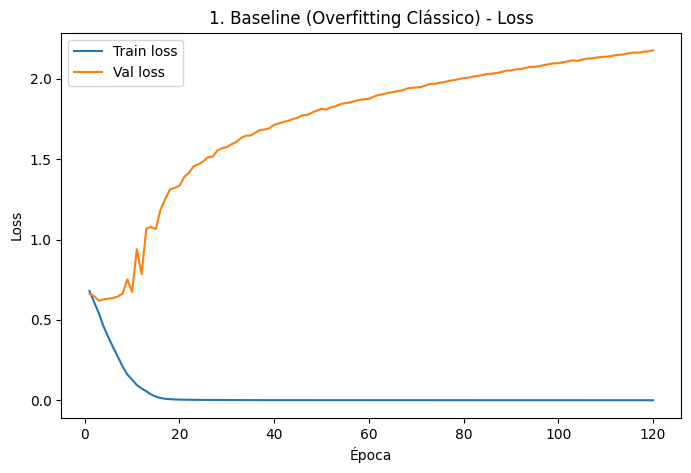

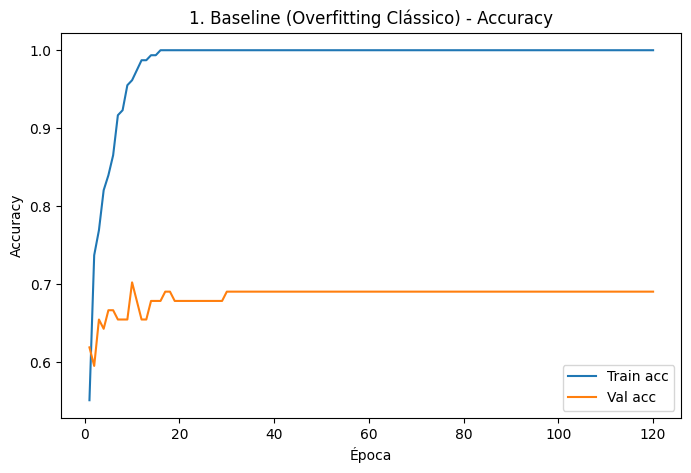

In [9]:
# 1. BASELINE (Sem Regularização)
print("--- Rodando Experimento 1: Baseline ---")
model_base = MLPOverfit(X_train_t.shape[1]).to(device)
optimizer_base = torch.optim.Adam(model_base.parameters(), lr=1e-3)

history_base = train_model(model_base, train_loader, val_loader, criterion, optimizer_base, epochs=120)
plot_history(history_base, title="1. Baseline (Overfitting Clássico)")

--- Rodando Experimento 2: Apenas L2 ---
Epoch 000 | train_loss=0.6776 val_loss=0.6627 | train_acc=0.5449 val_acc=0.5476
Epoch 010 | train_loss=0.0743 val_loss=0.9784 | train_acc=0.9872 val_acc=0.6429
Epoch 020 | train_loss=0.0039 val_loss=1.5498 | train_acc=1.0000 val_acc=0.6071
Epoch 030 | train_loss=0.0022 val_loss=1.6426 | train_acc=1.0000 val_acc=0.6310
Epoch 040 | train_loss=0.0019 val_loss=1.6431 | train_acc=1.0000 val_acc=0.6310
Epoch 050 | train_loss=0.0018 val_loss=1.6422 | train_acc=1.0000 val_acc=0.6310
Epoch 060 | train_loss=0.0017 val_loss=1.6439 | train_acc=1.0000 val_acc=0.6190
Epoch 070 | train_loss=0.0015 val_loss=1.6210 | train_acc=1.0000 val_acc=0.6310
Epoch 080 | train_loss=0.0014 val_loss=1.6742 | train_acc=1.0000 val_acc=0.6190
Epoch 090 | train_loss=0.0012 val_loss=1.6815 | train_acc=1.0000 val_acc=0.6190
Epoch 100 | train_loss=0.0012 val_loss=1.6743 | train_acc=1.0000 val_acc=0.6071
Epoch 110 | train_loss=0.0012 val_loss=1.6688 | train_acc=1.0000 val_acc=0.6071

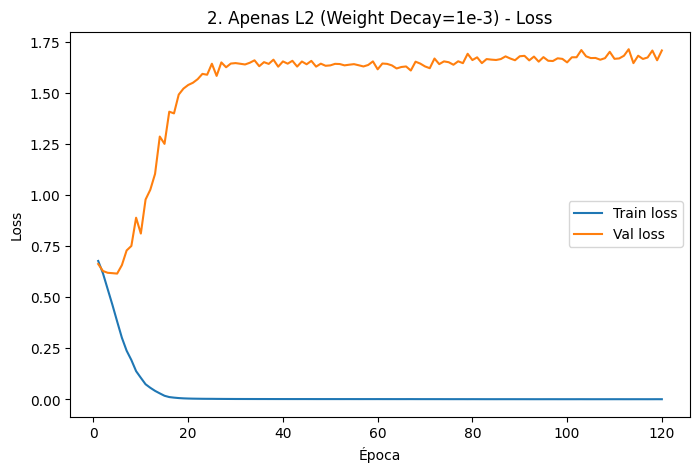

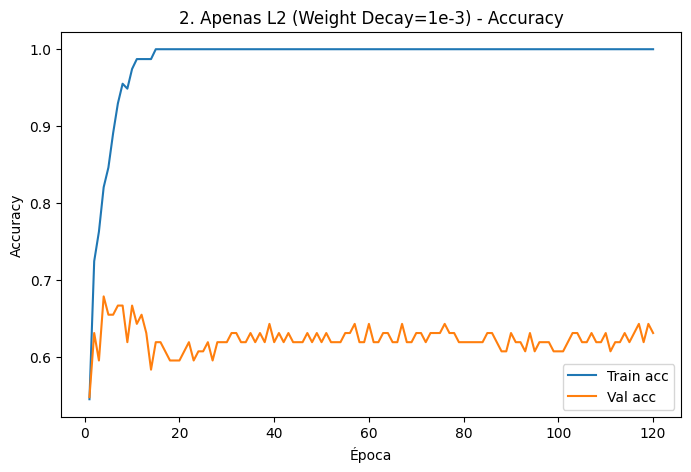

In [10]:
# 2. APENAS L2 (Weight Decay)
print("--- Rodando Experimento 2: Apenas L2 ---")
model_l2 = MLPOverfit(X_train_t.shape[1]).to(device)
# Adicionando weight_decay (L2) de 1e-3
optimizer_l2 = torch.optim.Adam(model_l2.parameters(), lr=1e-3, weight_decay=1e-3)

history_l2 = train_model(model_l2, train_loader, val_loader, criterion, optimizer_l2, epochs=120)
plot_history(history_l2, title="2. Apenas L2 (Weight Decay=1e-3)")

--- Rodando Experimento 3: Apenas Dropout ---
Epoch 000 | train_loss=0.6880 val_loss=0.6852 | train_acc=0.5449 val_acc=0.5595
Epoch 010 | train_loss=0.4280 val_loss=0.6196 | train_acc=0.8077 val_acc=0.6905
Epoch 020 | train_loss=0.2539 val_loss=0.7115 | train_acc=0.9167 val_acc=0.7262
Epoch 030 | train_loss=0.2109 val_loss=0.8991 | train_acc=0.9038 val_acc=0.7024
Epoch 040 | train_loss=0.1244 val_loss=1.0960 | train_acc=0.9487 val_acc=0.6429
Epoch 050 | train_loss=0.1214 val_loss=1.1416 | train_acc=0.9551 val_acc=0.7024
Epoch 060 | train_loss=0.0367 val_loss=1.7628 | train_acc=0.9936 val_acc=0.6310
Epoch 070 | train_loss=0.1529 val_loss=1.6563 | train_acc=0.9615 val_acc=0.6548
Epoch 080 | train_loss=0.0842 val_loss=1.7094 | train_acc=0.9679 val_acc=0.6548
Epoch 090 | train_loss=0.0792 val_loss=1.6703 | train_acc=0.9744 val_acc=0.6310
Epoch 100 | train_loss=0.0638 val_loss=1.8333 | train_acc=0.9679 val_acc=0.6429
Epoch 110 | train_loss=0.0595 val_loss=1.8064 | train_acc=0.9872 val_acc=0

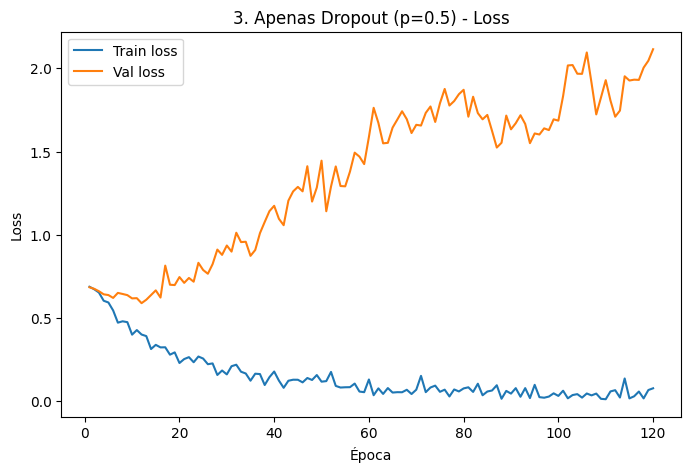

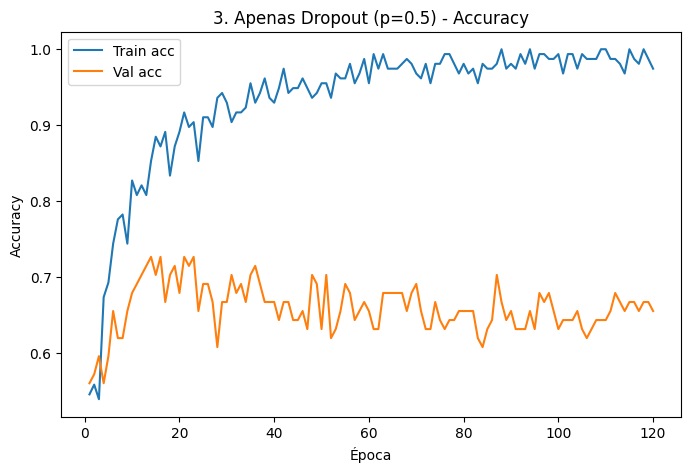

In [11]:
# 3. APENAS DROPOUT
print("--- Rodando Experimento 3: Apenas Dropout ---")

class MLPDropout(nn.Module):
    def __init__(self, input_dim, p=0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(p), # Dropout agressivo
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(p), # Dropout agressivo
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.net(x)

model_drop = MLPDropout(X_train_t.shape[1], p=0.5).to(device)
# Otimizador padrão, sem weight_decay
optimizer_drop = torch.optim.Adam(model_drop.parameters(), lr=1e-3)

history_drop = train_model(model_drop, train_loader, val_loader, criterion, optimizer_drop, epochs=120)
plot_history(history_drop, title="3. Apenas Dropout (p=0.5)")

--- Rodando Experimento 4: Combo Completo ---
Epoch 000 | train_loss=0.6942 val_loss=0.6880 | train_acc=0.5000 val_acc=0.5476
Epoch 010 | train_loss=0.4225 val_loss=0.6582 | train_acc=0.8333 val_acc=0.6429
Epoch 020 | train_loss=0.2944 val_loss=0.7584 | train_acc=0.8526 val_acc=0.6429
Epoch 030 | train_loss=0.2024 val_loss=0.8791 | train_acc=0.9167 val_acc=0.6190
Epoch 040 | train_loss=0.1325 val_loss=1.0672 | train_acc=0.9487 val_acc=0.6429
Epoch 050 | train_loss=0.0947 val_loss=1.2514 | train_acc=0.9615 val_acc=0.6429
Epoch 060 | train_loss=0.0542 val_loss=1.4769 | train_acc=0.9872 val_acc=0.6071
Epoch 070 | train_loss=0.0551 val_loss=1.5854 | train_acc=0.9872 val_acc=0.6667
Epoch 080 | train_loss=0.0414 val_loss=1.6875 | train_acc=0.9936 val_acc=0.6429
Epoch 090 | train_loss=0.0305 val_loss=1.6713 | train_acc=1.0000 val_acc=0.6786
Epoch 100 | train_loss=0.0276 val_loss=2.0052 | train_acc=0.9936 val_acc=0.6548
Epoch 110 | train_loss=0.0264 val_loss=2.1048 | train_acc=0.9872 val_acc=0

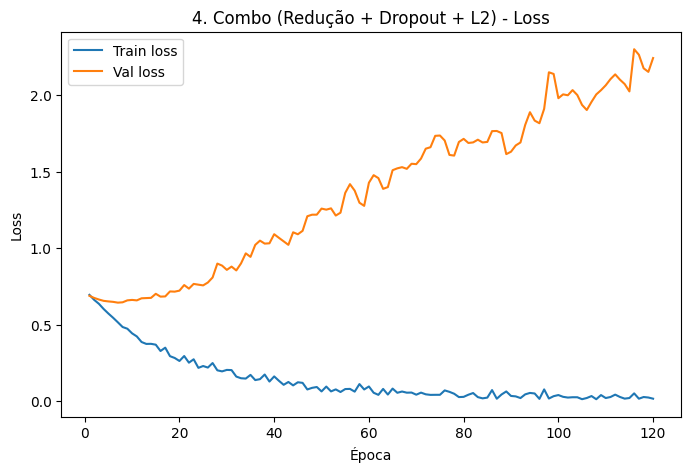

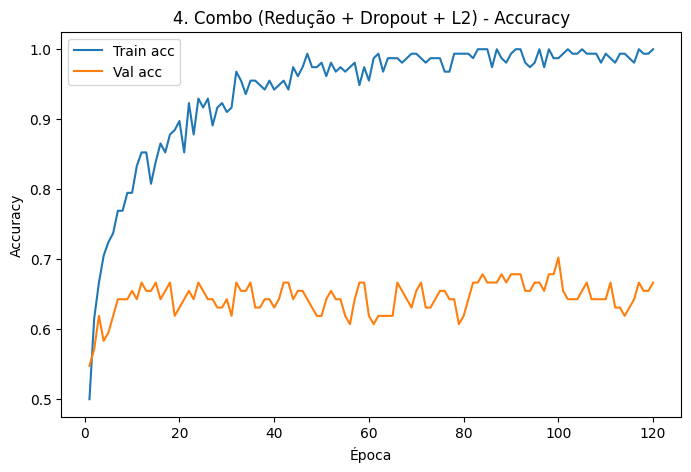

In [ ]:
# 4. COMBO (Arquitetura Menor + Dropout + L2)
print("--- Rodando Experimento 4: Combo Completo ---")

class MLPRegularized(nn.Module):
    def __init__(self, input_dim, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), # Arquitetura reduzida
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.net(x)

model_combo = MLPRegularized(X_train_t.shape[1], dropout=0.3).to(device)
# Otimizador com weight_decay suave
optimizer_combo = torch.optim.Adam(model_combo.parameters(), lr=1e-3, weight_decay=1e-4)

history_combo = train_model(model_combo, train_loader, val_loader, criterion, optimizer_combo, epochs=120)
plot_history(history_combo, title="4. Combo (Redução + Dropout + L2)")

## 5. Registro final

Monte uma tabela com suas execuções:

| Configuração | Train Acc Final | Val Acc Final | Gap | Interpretação |
|---|---:|---:|---:|---|
| Baseline | 100% | 69,0% | 31,0% | Overfitting severo |
| + L2 | 100% | 63,1% | 36,9% | Piorou a generalização |
| + Dropout | 97% | 65,5% | 31,9% | Atrasou o overfitting |
| L2 + Dropout | 100% | 66,7% | 33,3% | Efeito misto |

## Conclusão
Responda:
- Qual configuração teve melhor capacidade de generalização?

O Dropout. Embora o Baseline tenha terminado a época 120 com a maior validação matemática (69%), o modelo com Dropout foi o único que demonstrou potencial real de aprendizado antes de overfitar. Na época 20, o Dropout atingiu 72,6% de acurácia na validação (o maior valor de todos os experimentos). Isso prova que, se parar o treino na época 20, o Dropout seria o grande vencedor.

- Qual configuração apenas reduziu desempenho sem melhorar generalização?

O Apenas L2 (Weight Decay). Ele manteve a acurácia de treino em perfeitos 100%, mas derrubou a acurácia de validação para 63,1%, aumentando o gap de generalização para quase 37%. Nesse cenário com poucos dados, a penalidade nos pesos apenas "engessou" a rede, impedindo-a de aprender até mesmo os padrões úteis que o Baseline havia encontrado, sem conseguir evitar a memorização.